In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

In [27]:
df = pd.read_csv('admission.csv')

In [28]:
df.shape

(400, 4)

In [29]:
df.head()

,ADMIT,GRE,GPA,RANK
0,0,380,3.61,3
1,1,660,3.67,3
2,1,800,4.00,1
3,1,640,3.19,4
4,0,520,2.93,4


In [30]:
df.duplicated().sum()

np.int64(5)

In [31]:
df.drop_duplicates(ignore_index = True,inplace = True)

In [32]:
df.duplicated().sum()

np.int64(0)

In [33]:
df.isnull().sum()

ADMIT    0
GRE      0
GPA      0
RANK     0
dtype: int64

In [34]:
target = df[['ADMIT']]
features = df.drop(columns = ['ADMIT'])

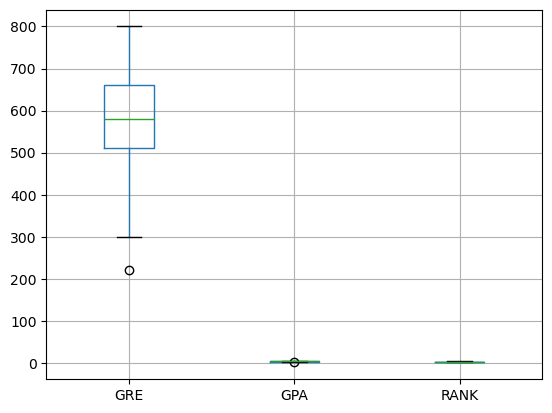

In [36]:
plt.clf()   # Clear current figure
features.boxplot()
plt.show()

In [37]:
def outlier_capping(df,column):
    Q1= df[column].quantile(0.25)
    Q3= df[column].quantile(0.75)
    IQR= Q3-Q1
    lower_extreme= Q1-1.5*IQR
    upper_extreme= Q3+1.5*IQR
    df[column]= df[column].apply(lambda x: lower_extreme if x< lower_extreme else upper_extreme if x>upper_extreme else x)
for col in features.select_dtypes(include=['int','float']).columns:
    outlier_capping(features,col)

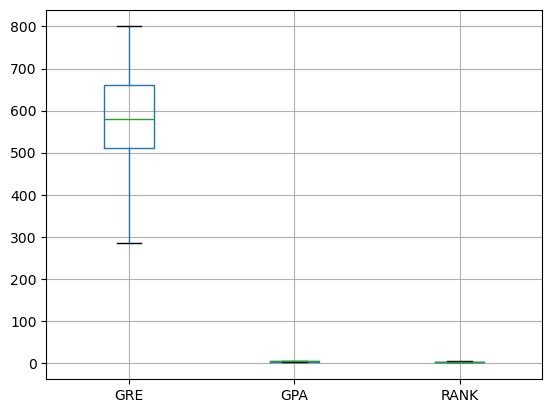

In [38]:
features.boxplot()
plt.show()

In [39]:
from sklearn.feature_selection import f_classif

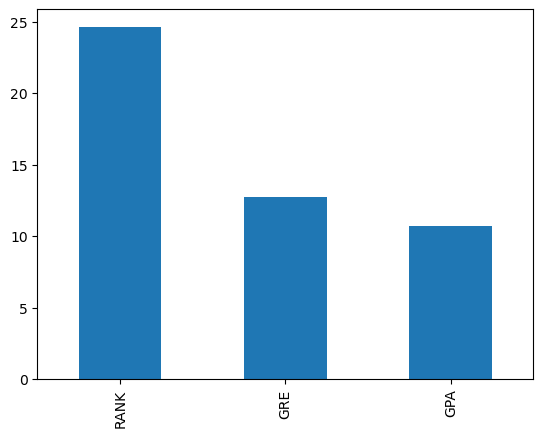

In [40]:
f_clas= f_classif(features,target)

pd.Series(f_clas[0],index=features.columns).sort_values(ascending=False).plot(kind='bar')

plt.show()

In [41]:
#### Train_test_split

x_train,x_test,y_train,y_test= train_test_split(features,target,train_size=0.8,random_state=100)

print(x_train.shape)

print(x_test.shape)

print(y_train.shape)

print(y_test.shape)

(316, 3)
(79, 3)
(316, 1)
(79, 1)


In [42]:
## scaling
std_sca = StandardScaler()
x_train[['GRE','GPA']] = std_sca.fit_transform(x_train[['GRE','GPA']])
x_test[['GRE','GPA']] = std_sca.transform(x_test[['GRE','GPA']])

In [44]:
log_model = LogisticRegression()
log_model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [45]:
log_model.intercept_

array([0.34852378])

In [46]:
log_model.coef_

array([[ 0.29695952,  0.24709696, -0.4921554 ]])

In [47]:
## training validation
y_pred = log_model.predict(x_train)
accuracy_score(y_train,y_pred)

0.6993670886075949

In [48]:
## training validation
y_pred1 = log_model.predict(x_test)
accuracy_score(y_test,y_pred1)

0.6835443037974683

In [50]:
sigmoid = log_model.predict_proba(x_test)[:,1]

array([0.30944428, 0.55818439, 0.31835178, 0.53478823, 0.27461763,
       0.22603844, 0.62051269, 0.16764209, 0.19320207, 0.21372138,
       0.22251141, 0.1971961 , 0.22215307, 0.24727472, 0.12046182,
       0.06002437, 0.35525343, 0.41317419, 0.20763271, 0.54777384,
       0.10706144, 0.27208292, 0.15879212, 0.15388372, 0.33694712,
       0.16315164, 0.19462167, 0.14618552, 0.40693938, 0.09155421,
       0.1626842 , 0.43673391, 0.16719937, 0.25575327, 0.292909  ,
       0.31352242, 0.2679566 , 0.14899675, 0.31699602, 0.26344963,
       0.19670918, 0.42519542, 0.3319514 , 0.53453795, 0.41872499,
       0.48363247, 0.57200332, 0.29750592, 0.20727594, 0.38570636,
       0.55055966, 0.35720696, 0.39487594, 0.14717705, 0.20838851,
       0.30283485, 0.26787706, 0.53561666, 0.27243174, 0.35542628,
       0.44444185, 0.16233365, 0.15686195, 0.21522551, 0.33517959,
       0.16027967, 0.38121069, 0.25304653, 0.38939195, 0.1253437 ,
       0.43328845, 0.23212215, 0.19735543, 0.35315371, 0.24157

performance matrics


In [51]:
## confusion matrics

In [53]:
from sklearn.metrics import confusion_matrix, classification_report 

In [55]:
conf = confusion_matrix(y_test,y_pred1)
conf

array([[50,  4],
       [21,  4]])

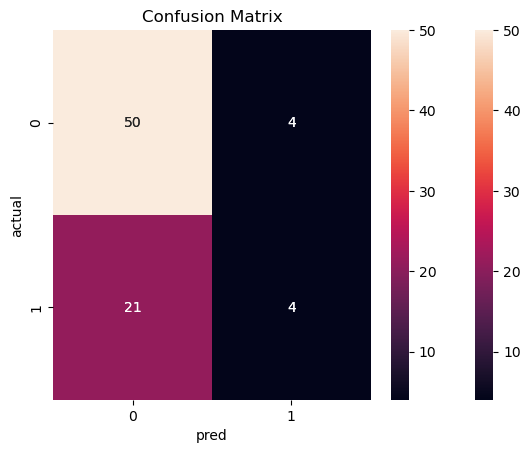

In [57]:
sns.heatmap(conf,annot = True)
plt.title('Confusion Matrix')
plt.xlabel('pred')
plt.ylabel('actual')
plt.show()